# PL vs Boltzmann: downstream evaluation head-to-head

The Boltzmann (moment-matching) fit matches marginals and pair co-occurrence far better
than pseudo-likelihood (PL). But does that better generative calibration actually help on
the tasks the app cares about? PL matches *conditionals* (predict a held-out member given
the rest), which is exactly what completion/ranking needs. Boltzmann matches *moments*
(marginals + pair co-occurrence), which is better for generation/scoring/discrimination.

This notebook runs five head-to-head metrics on the **same train/test split**, with the
same vocab, same weighting, and the same eval code. Only the fitted `(J, h)` differ.

1. **Out-of-time completion** (leave-one-out MRR / hit-rate) -- PL's home turf.
2. **Held-out log-pseudo-likelihood** (LPPL) -- the conditional objective evaluated out-of-sample.
3. **Real-vs-null energy discrimination** (AUC + field_weight sweep) -- Boltzmann's home turf.
4. **Held-out pair co-occurrence calibration** -- moment matching evaluated out-of-sample.
5. **Outcome association** (Score/coherence vs placement + ICC ceiling).

**Critical design choice**: `field_weight` is swept independently for each model. PL's
$h$ is over-weighted (AUC peaks around fw $\approx$ 0.3-0.5); Boltzmann matches marginals
at fw $\approx$ 1. A fair comparison reports each model at its own optimum.

In [1]:
from __future__ import annotations

from collections import Counter
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata, spearmanr
from scipy.special import expit, log_expit

from k2dex import tournament_ingest
from k2dex.constants import (
    PHASE2_MIN_TEAM_COUNT, TEAM_SIZE,
    SPECIES_ITEM_LR_LAMBDA, SPECIES_LR_LAMBDA,
    RECENCY_TAU_DAYS, IN_PERSON_WEIGHT,
    VALIDATION_TEAM_FRAC_TEST, VALIDATION_SEED,
)
from k2dex.loaders import format_pair, team_weights
from k2dex.models import fit_pl_ising, fit_boltzmann_ising, empirical_moments
from k2dex.sampling import team_energy
from k2dex.rendering import intra_team_sum_j

# ── Configuration ────────────────────────────────────────────────────────────
# Change these two to switch regulation or model type.
REG = "M-A"
MODEL = "species_item"   # "species" or "species_item"

LAM = SPECIES_ITEM_LR_LAMBDA if MODEL == "species_item" else SPECIES_LR_LAMBDA

# Boltzmann fit knobs (warm-started from PL; tuned in boltzmann_learning.ipynb).
BZ_OPTS = dict(
    reg="l2", reg_lambda=1e-3,
    n_iters=500, lr=0.01, lr_final=0.0001,
    n_chains=500, n_sweeps=500, n_burn=200,
    avg_last=100, n_temps=1,
    support_min_count=10 if MODEL == "species_item" else None,
)

SEED = 42
K_VALUES = [1, 2, 3]
TOP_K_THRESHOLDS = [1, 5, 10, 20]

print(f"regulation: {REG}   model: {MODEL}   lambda: {LAM}")
print(f"Boltzmann knobs: {BZ_OPTS}")

regulation: M-A   model: species_item   lambda: 4.5
Boltzmann knobs: {'reg': 'l2', 'reg_lambda': 0.001, 'n_iters': 500, 'lr': 0.01, 'lr_final': 0.0001, 'n_chains': 500, 'n_sweeps': 500, 'n_burn': 200, 'avg_last': 100, 'n_temps': 1, 'support_min_count': 10}


## Train/test split + vocab

Chronological 90/10 at tournament boundaries, identical to `validation.ipynb`. Vocab
from **train only**; test teams with any OOV member are dropped. Weighted fit uses
`RECENCY_TAU_DAYS` / `IN_PERSON_WEIGHT` from constants.

In [2]:
tournaments = tournament_ingest.load_cached_tournaments(regulation=REG)
train_tournaments, test_tournaments = tournament_ingest.chronological_split(
    tournaments, train_frac=1.0 - VALIDATION_TEAM_FRAC_TEST,
)

train_teams_full = tournament_ingest.all_teams(train_tournaments)
train_obs = tournament_ingest.all_team_observations(train_tournaments)
ref_date = max(t.meta.date for t in train_tournaments)
test_teams_full = tournament_ingest.all_teams(test_tournaments)

w = team_weights(
    train_obs, reference_date=ref_date,
    recency_tau=RECENCY_TAU_DAYS, in_person_multiplier=IN_PERSON_WEIGHT,
)

n_total = len(train_teams_full) + len(test_teams_full)
print(
    f"chronological split (test_frac={VALIDATION_TEAM_FRAC_TEST:.0%})\n"
    f"train: {len(train_teams_full):>6} teams ({len(train_teams_full)/n_total:.1%})  "
    f"{train_tournaments[0].meta.date} -> {train_tournaments[-1].meta.date}\n"
    f"test:  {len(test_teams_full):>6} teams ({len(test_teams_full)/n_total:.1%})  "
    f"{test_tournaments[0].meta.date} -> {test_tournaments[-1].meta.date}"
)

chronological split (test_frac=10%)
train:  23159 teams (90.1%)  2026-04-09T16:00:00.000Z -> 2026-06-07T13:30:00.000Z
test:    2545 teams (9.9%)  2026-06-07T15:00:00.000Z -> 2026-06-16T17:00:00.000Z


In [3]:
def build_vocab_and_matrix(teams_full, w, *, min_count=PHASE2_MIN_TEAM_COUNT, model=MODEL):
    """Build vocab, feature matrix, species/item lookups from a team list.

    Returns (vocab, feature_to_idx, X, species_of, item_of).
    - species model: features are species strings; species_of=None, item_of=None.
    - species_item model: features are (species, item) pairs; lookups populated.
    """
    if model == "species":
        teams = tournament_ingest.species_only_teams(teams_full)
        raw = Counter(name for team in teams for name in team)
        wcounts: dict = {}
        for ti, team in enumerate(teams):
            for name in team:
                wcounts[name] = wcounts.get(name, 0.0) + w[ti]
        vocab = sorted(
            name for name, c in wcounts.items()
            if c >= min_count and raw[name] >= min_count
        )
        feat_to_idx = {name: i for i, name in enumerate(vocab)}
        V = len(vocab)
        X = np.zeros((len(teams), V), dtype=np.int8)
        for ti, team in enumerate(teams):
            for name in team:
                j = feat_to_idx.get(name)
                if j is not None:
                    X[ti, j] = 1
        return vocab, feat_to_idx, X, None, None

    # species_item
    raw = Counter(pair for team in teams_full for pair in team)
    wcounts = {}
    for ti, team in enumerate(teams_full):
        for pair in team:
            wcounts[pair] = wcounts.get(pair, 0.0) + w[ti]
    pair_list = sorted(
        (p for p, c in wcounts.items()
         if c >= min_count and raw[p] >= min_count),
        key=lambda p: format_pair(p[0], p[1]),
    )
    vocab = [format_pair(s, i) for s, i in pair_list]
    feat_to_idx = {p: i for i, p in enumerate(pair_list)}
    V = len(vocab)
    species_of = [s for s, _ in pair_list]
    item_of: list[str | None] = [it for _, it in pair_list]
    X = np.zeros((len(teams_full), V), dtype=np.int8)
    for ti, team in enumerate(teams_full):
        for pair in team:
            j = feat_to_idx.get(pair)
            if j is not None:
                X[ti, j] = 1
    return vocab, feat_to_idx, X, species_of, item_of


vocab, feat_to_idx, X_train, species_of, item_of = build_vocab_and_matrix(
    train_teams_full, w,
)
V = len(vocab)
m_train = (w @ X_train) / w.sum()

print(f"vocab size: {V}")
print(f"m_train range: [{m_train.min():.4f}, {m_train.max():.4f}]")
print(f"species_of: {'populated' if species_of else 'None'}")
print(f"item_of:    {'populated' if item_of else 'None'}")

vocab size: 891
m_train range: [0.0001, 0.3036]
species_of: populated
item_of:    populated


## Fit both models on the train split

PL and Boltzmann are fit on the **same train data**, same vocab, same weights. Boltzmann
warm-starts from the PL fit (the standard pipeline). Both fits produce `(J, h)` on the
same index order, so every downstream metric applies identically.

In [4]:
X_train_int = X_train.astype(np.int32)

# ── PL fit ────────────────────────────────────────────────────────────────────
J_pl, h_pl = fit_pl_ising(X_train_int, C=1.0 / LAM, sample_weight=w)

iu = np.triu_indices(V, 1)
print("PL fit")
print(f"  J off-diag: [{J_pl[iu].min():+.3f}, {J_pl[iu].max():+.3f}]")
print(f"  h range:    [{h_pl.min():+.3f}, {h_pl.max():+.3f}]")

# ── Boltzmann fit (warm-started from PL) ──────────────────────────────────────
bz_kw = dict(BZ_OPTS)
support_min = bz_kw.pop("support_min_count", None)
support_mask = None
if support_min is not None:
    cooc = X_train_int.astype(np.int64).T @ X_train_int.astype(np.int64)
    support_mask = cooc >= int(support_min)
    print(f"\nsupport mask: {int(support_mask.sum())} entries >= {support_min}")

J_bz, h_bz, history = fit_boltzmann_ising(
    X_train_int, team_size=TEAM_SIZE, sample_weight=w,
    init_J=J_pl, init_h=h_pl,
    species_of=species_of, item_of=item_of,
    support_mask=support_mask, seed=SEED,
    **bz_kw,
)

print(f"\nBoltzmann fit")
print(f"  J off-diag: [{J_bz[iu].min():+.3f}, {J_bz[iu].max():+.3f}]")
print(f"  h range:    [{h_bz.min():+.3f}, {h_bz.max():+.3f}]")
print(f"  final mean_resid_m: {history['mean_resid_m'][-1]:.5f}")
print(f"  final mean_resid_C: {history['mean_resid_C'][-1]:.5f}")

PL fit
  J off-diag: [-5.273, +3.871]
  h range:    [-9.079, +3.259]

support mask: 8948 entries >= 10


boltzmann fit:   0%|          | 0/500 [00:00<?, ?it/s]


Boltzmann fit
  J off-diag: [-5.273, +3.617]
  h range:    [-6.740, +2.647]
  final mean_resid_m: 0.00183
  final mean_resid_C: 0.00152


In [5]:
# ── Test set: filter to in-vocab teams ────────────────────────────────────────
def team_to_indices(team_full, feat_to_idx, model=MODEL):
    """Map a team to vocab indices. Returns None if any member is OOV."""
    if model == "species":
        species = {s for s, _ in team_full}
        if len(species) != TEAM_SIZE:
            return None
        out = []
        for s in sorted(species):
            j = feat_to_idx.get(s)
            if j is None:
                return None
            out.append(j)
        return out
    out = []
    for pair in sorted(team_full, key=lambda p: (p[0], p[1] or "")):
        j = feat_to_idx.get(pair)
        if j is None:
            return None
        out.append(j)
    return out


in_vocab_test = []
in_vocab_test_idx = []
for team in test_teams_full:
    if len(team) != TEAM_SIZE:
        continue
    idx = team_to_indices(team, feat_to_idx)
    if idx is None:
        continue
    in_vocab_test.append(team)
    in_vocab_test_idx.append(np.array(idx))

print(f"in-vocab test teams: {len(in_vocab_test)} / {len(test_teams_full)}")

# Convenience: dict of {name: (J, h)} for iteration.
models = {"PL": (J_pl, h_pl), "Boltzmann": (J_bz, h_bz)}

in-vocab test teams: 2418 / 2545


## Metric 1: Out-of-time completion (MRR / hit-rate)

For each test team and each $k \in \{1, 2, 3\}$, hold out $k$ random members, score
every candidate via damped mean-field marginals (held-in members clamped to 1), rank,
and measure MRR + top-K hit rate. This is PL's **home turf**: PL directly maximizes the
conditional $P(x_i \mid x_{\backslash i})$, which is what this metric tests.

Species/item uniqueness masking is applied identically under both models: candidates
sharing a species or item with any held-in member are masked out before ranking.

> **Inference-path caveat.** This uses mean-field, but production ranking is PT-MCMC. MF
> was validated as a ranking-faithful proxy *for PL* at fw=1 (`validation.ipynb`); it is
> **not** validated for Boltzmann's flatter, moment-matched parameterization, and the MF
> marginal diagnostic in Metric 4 shows MF over-concentrates on PL's sharp $J$. So read
> the PL-vs-Boltzmann *gap* here cautiously — if MF distorts the two fits differently, the
> ranking comparison is biased. A PT-MCMC completion spot-check (mirroring
> `validation.ipynb`'s MF-vs-MCMC agreement cell) is the way to confirm the gap is real.

In [6]:
def score_meanfield(held_in_idx, *, J, h, n_iters=200, tol=1e-4, damp=0.5):
    """Mean-field marginals with held-in indices clamped to 1."""
    V_loc = len(h)
    fixed = np.zeros(V_loc, dtype=bool)
    fixed[list(held_in_idx)] = True
    m = 1.0 / (1.0 + np.exp(-h))
    m[fixed] = 1.0
    for _ in range(n_iters):
        m_new = 1.0 / (1.0 + np.exp(-(h + J @ m)))
        m_new[fixed] = 1.0
        delta = float(np.max(np.abs(m_new[~fixed] - m[~fixed])))
        m = damp * m_new + (1.0 - damp) * m
        m[fixed] = 1.0
        if delta < tol:
            break
    return m


def uniqueness_mask(held_in_idx, *, species_of, item_of, V):
    """Mask of vocab entries that conflict with held-in members (species or item)."""
    mask = np.zeros(V, dtype=bool)
    mask[list(held_in_idx)] = True
    if species_of is not None:
        held_sp = {species_of[i] for i in held_in_idx}
        for i in range(V):
            if species_of[i] in held_sp:
                mask[i] = True
    if item_of is not None:
        held_it = {item_of[i] for i in held_in_idx if item_of[i] is not None}
        if held_it:
            for i in range(V):
                if item_of[i] is not None and item_of[i] in held_it:
                    mask[i] = True
    return mask


rng = np.random.default_rng(SEED)
completion_results = {name: {k: [] for k in K_VALUES} for name in models}

for team_idx in tqdm(in_vocab_test_idx, desc="Teams evaluated"):
    for k in K_VALUES:
        held_out_pos = rng.choice(TEAM_SIZE, size=k, replace=False)
        held_in_pos = np.delete(np.arange(TEAM_SIZE), held_out_pos)
        held_in_idx = team_idx[held_in_pos]
        held_out_idx = team_idx[held_out_pos]
        invalid = uniqueness_mask(
            held_in_idx, species_of=species_of, item_of=item_of, V=V,
        )
        for name, (J, h) in models.items():
            scores = score_meanfield(held_in_idx, J=J, h=h).copy()
            scores[invalid] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            completion_results[name][k].append(rank_of[held_out_idx])

for name in models:
    for k in K_VALUES:
        completion_results[name][k] = np.array(completion_results[name][k])

print(f"evaluated {len(in_vocab_test_idx)} teams x {len(K_VALUES)} k values x {len(models)} models")

Teams evaluated: 100%|██████████| 2418/2418 [01:35<00:00, 25.28it/s]

evaluated 2418 teams x 3 k values x 2 models


In [7]:
def hit_rate_at_k(ranks, K):
    return float((ranks <= K).mean())

def mrr(ranks):
    return float((1.0 / ranks).mean())

header = f"{'model':<12} {'k':>2}  {'MRR':>6}  " + "  ".join(
    f"top-{K:>2}" for K in TOP_K_THRESHOLDS
)
print(header)
print("-" * len(header))
for name in models:
    for k in K_VALUES:
        ranks = completion_results[name][k]
        row = f"{name:<12} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(
            f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS
        )
        print(row)
    print()

model         k     MRR  top- 1  top- 5  top-10  top-20
-------------------------------------------------------
PL            1   0.545   42.8%   68.1%   78.0%   84.7%
PL            2   0.404   24.1%   59.1%   71.7%   81.1%
PL            3   0.309   16.0%   47.5%   63.3%   76.0%

Boltzmann     1   0.535   45.7%   61.6%   69.4%   77.5%
Boltzmann     2   0.405   25.7%   55.9%   64.7%   73.2%
Boltzmann     3   0.319   17.4%   49.0%   57.9%   67.5%



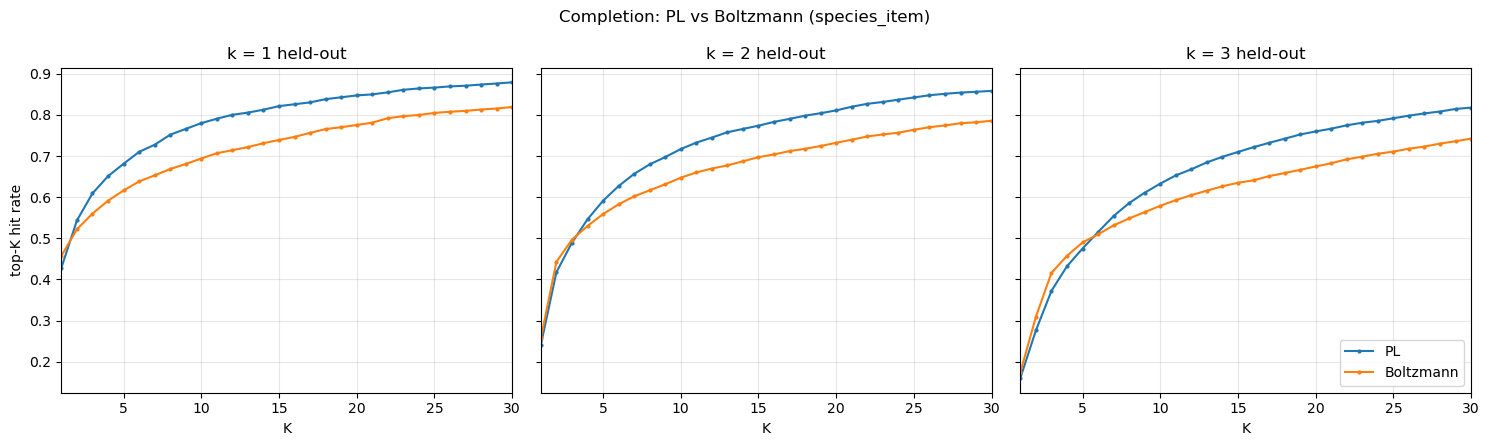

In [8]:
K_RANGE = list(range(1, 31))

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 4.5), sharey=True)
for ax, k in zip(axes, K_VALUES):
    for name in models:
        ranks = completion_results[name][k]
        hits = [hit_rate_at_k(ranks, K) for K in K_RANGE]
        ax.plot(K_RANGE, hits, label=name, marker=".", markersize=4)
    ax.set_xlabel("K")
    ax.set_title(f"k = {k} held-out")
    ax.grid(alpha=0.3)
    ax.set_xlim(1, K_RANGE[-1])
axes[0].set_ylabel("top-K hit rate")
axes[-1].legend(loc="lower right")
fig.suptitle(f"Completion: PL vs Boltzmann ({MODEL})")
plt.tight_layout()
plt.show()

### Completion spot-check: MF vs MCMC (production path)

MF distorted the two fits unequally in the marginal diagnostic, so the completion gap
above needs confirmation under the production sampler. This runs single-chain swap-MCMC
at fw=1, T=1 over the $k$ free slots with held-in clamped — the same target distribution
the webapp samples (no PT needed at T=1, where there is no multimodality to defeat) —
on a subset of test teams, and compares it head-to-head with MF on the **same held-out
positions**. Mirrors `validation.ipynb`'s MF-vs-MCMC agreement cell.

Two reads: (1) does the **PL-vs-Boltzmann ordering** survive the switch from MF to MCMC,
and (2) is MF a **faithful proxy** for each model individually (top-1 match + rank
Spearman). If MF agrees with MCMC for PL but not Boltzmann, the Metric 1 gap is partly an
MF artifact.

In [9]:
from k2dex.sampling import swap_mcmc

# Spot-check knobs. This is the slow cell: COMPARE_N teams x len(K_VALUES) x
# 2 models chains, each (MC_BURN + MC_SAMPLE) Python-level swap steps. The
# completion comparison is the low-powered one (vs the full-corpus LPPL and PT
# calibration), so it's worth a larger COMPARE_N to settle the completer
# question. Two noise sources: team sampling (raise COMPARE_N) and per-problem
# MCMC marginal estimation over ~V candidates (raise MC_SAMPLE). Both matter.
COMPARE_N = 150
MC_BURN = 3000
MC_SAMPLE = 20000


def mcmc_completion_marginal(held_in_idx, J, h, seed):
    """Per-candidate appearance frequency from swap-MCMC at fw=1, T=1 with
    held_in_idx clamped on. team_size - len(held_in) free slots are sampled
    under the same uniqueness rules the webapp enforces. Returns length-V
    marginals (held-in entries ~1), or None if over-constrained."""
    res = swap_mcmc(
        J, h, TEAM_SIZE, [int(i) for i in held_in_idx], [], 1.0,
        MC_BURN + MC_SAMPLE, 1.0, seed,
        species_of=species_of, item_of=item_of,
    )
    if res is None:
        return None
    samples, _acc = res
    return samples[MC_BURN:].mean(axis=0)


rng_sc = np.random.default_rng(SEED)
methods = ["MF", "MCMC"]
sc_results = {
    name: {meth: {k: [] for k in K_VALUES} for meth in methods}
    for name in models
}

compare_idx = in_vocab_test_idx[:COMPARE_N]
for ti, team_idx in tqdm(enumerate(compare_idx), total=COMPARE_N, desc="Teams checked"):
    for k in K_VALUES:
        held_out_pos = rng_sc.choice(TEAM_SIZE, size=k, replace=False)
        held_in_pos = np.delete(np.arange(TEAM_SIZE), held_out_pos)
        held_in_idx = team_idx[held_in_pos]
        held_out_idx = team_idx[held_out_pos]
        invalid = uniqueness_mask(
            held_in_idx, species_of=species_of, item_of=item_of, V=V,
        )
        for name, (J, h) in models.items():
            mf_scores = score_meanfield(held_in_idx, J=J, h=h)
            mc_marg = mcmc_completion_marginal(
                held_in_idx, J, h, SEED + ti * 100 + k,
            )
            assert mc_marg is not None, "over-constrained completion problem"
            for meth, scores in [("MF", mf_scores), ("MCMC", mc_marg)]:
                s = scores.astype(np.float64).copy()
                s[invalid] = -np.inf
                order = np.argsort(-s)
                rank_of = np.empty(V, dtype=np.int64)
                rank_of[order] = np.arange(1, V + 1)
                sc_results[name][meth][k].append(rank_of[held_out_idx])

for name in models:
    for meth in methods:
        for k in K_VALUES:
            sc_results[name][meth][k] = np.array(sc_results[name][meth][k])

print(f"\nspot-check: {COMPARE_N} teams x {len(K_VALUES)} k x {len(models)} models x MF/MCMC")

Teams checked: 100%|██████████| 150/150 [02:02<00:00,  1.22it/s]


spot-check: 150 teams x 3 k x 2 models x MF/MCMC


In [10]:
# ── (1) Does the PL-vs-Boltzmann ordering survive MF -> MCMC? ──────────────────
header = f"{'model':<12} {'method':<6} {'k':>2}  {'MRR':>6}  " + "  ".join(
    f"top-{K:>2}" for K in TOP_K_THRESHOLDS
)
print(header)
print("-" * len(header))
for name in models:
    for meth in methods:
        for k in K_VALUES:
            ranks = sc_results[name][meth][k].ravel()
            row = f"{name:<12} {meth:<6} {k:>2}  {mrr(ranks):>6.3f}  "
            row += "  ".join(
                f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS
            )
            print(row)
        print()

# ── (2) Is MF a faithful proxy for each model? ────────────────────────────────
print("MF vs MCMC agreement (same held-out problem)")
print(f"{'model':<12} {'k':>2}  {'top-1 match':>11}  {'rank Spearman':>14}")
print("-" * 44)
for name in models:
    for k in K_VALUES:
        mf_ranks = sc_results[name]["MF"][k].ravel()
        mc_ranks = sc_results[name]["MCMC"][k].ravel()
        mf_top = mf_ranks == 1
        mc_top = mc_ranks == 1
        union = (mf_top | mc_top).sum()
        top1_match = float((mf_top & mc_top).sum() / max(union, 1))
        rho, _ = spearmanr(mf_ranks, mc_ranks)
        print(f"{name:<12} {k:>2}  {top1_match:>10.1%}  {rho:>14.3f}")
    print()

model        method  k     MRR  top- 1  top- 5  top-10  top-20
--------------------------------------------------------------
PL           MF      1   0.569   45.3%   70.0%   81.3%   87.3%
PL           MF      2   0.458   28.7%   66.3%   78.7%   87.3%
PL           MF      3   0.335   18.0%   52.2%   68.4%   79.1%

PL           MCMC    1   0.572   44.7%   75.3%   81.3%   87.3%
PL           MCMC    2   0.448   26.7%   68.0%   80.0%   86.7%
PL           MCMC    3   0.332   18.9%   51.1%   64.4%   78.7%

Boltzmann    MF      1   0.594   52.7%   68.0%   72.7%   80.7%
Boltzmann    MF      2   0.441   28.3%   61.0%   71.3%   79.0%
Boltzmann    MF      3   0.332   17.1%   51.1%   62.7%   72.7%

Boltzmann    MCMC    1   0.617   50.7%   76.7%   85.3%   88.7%
Boltzmann    MCMC    2   0.477   30.0%   70.0%   79.0%   87.3%
Boltzmann    MCMC    3   0.348   18.0%   54.7%   67.6%   79.3%

MF vs MCMC agreement (same held-out problem)
model         k  top-1 match   rank Spearman
------------------------

In [11]:
# ── Paired bootstrap CI on the MCMC completion MRR gap (Boltzmann - PL) ────────
# Resample teams with replacement; both models share the resampled teams (paired),
# so the CI isolates the model difference from team-to-team variation. A 95% CI
# that excludes 0 means the production-path completion gap is real, not noise.
N_BOOT = 2000
boot_rng = np.random.default_rng(SEED)

print(f"{'k':>2}  {'PL MRR':>7} {'Bz MRR':>7} {'Δ(Bz-PL)':>9}  {'95% CI':>18}  {'P(Δ>0)':>7}")
print("-" * 62)
for k in K_VALUES:
    pl = 1.0 / sc_results["PL"]["MCMC"][k]          # (n, k) reciprocal ranks
    bz = 1.0 / sc_results["Boltzmann"]["MCMC"][k]
    n = pl.shape[0]
    pl_mrr = float(pl.mean())
    bz_mrr = float(bz.mean())
    diffs = np.empty(N_BOOT)
    for b in range(N_BOOT):
        idx = boot_rng.integers(n, size=n)
        diffs[b] = bz[idx].mean() - pl[idx].mean()
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_pos = float((diffs > 0).mean())
    print(f"{k:>2}  {pl_mrr:>7.3f} {bz_mrr:>7.3f} {bz_mrr - pl_mrr:>+9.3f}  "
          f"[{lo:>+6.3f}, {hi:>+6.3f}]  {p_pos:>6.1%}")

 k   PL MRR  Bz MRR  Δ(Bz-PL)              95% CI   P(Δ>0)
--------------------------------------------------------------
 1    0.572   0.617    +0.046  [+0.010, +0.083]   99.4%
 2    0.448   0.477    +0.030  [-0.001, +0.059]   97.1%
 3    0.332   0.348    +0.015  [-0.007, +0.037]   90.9%


## Metric 2: Held-out log-pseudo-likelihood (LPPL)

The PL objective itself, evaluated on the test set: for each test team and each feature
$i$, compute $\log P(x_i \mid x_{\backslash i}, J, h) = x_i \log\sigma(\eta_i) +
(1 - x_i) \log(1 - \sigma(\eta_i))$ where $\eta_i = h_i + J_{i,:} x_{\backslash i}$.
Sum over all $i$ and all test teams. Higher (less negative) is better.

PL maximizes this on **training** data by construction. The test-set evaluation asks
whether Boltzmann's better generative model transfers to better conditional prediction
out-of-sample, or whether PL's direct optimization of this objective gives it an edge.

In [12]:
def log_pseudo_likelihood(X, J, h):
    """Per-team mean log-pseudo-likelihood across all V conditionals.

    For each team t and feature i:
        eta_i = h_i + sum_{j != i} J_ij * x_j
        lppl_i = x_i * log(sigma(eta_i)) + (1 - x_i) * log(1 - sigma(eta_i))

    The sum over j != i uses J with zero diagonal (which both fits have), so
    eta = h + J @ x works directly -- J_ii * x_i = 0.

    Returns (total_lppl, per_team_mean_lppl) where total is summed over all
    teams and features, and per_team_mean divides by n_teams * V.
    """
    Xf = X.astype(np.float64)
    eta = Xf @ J + h[None, :]   # (n, V): eta_i = h_i + sum_j J_ij x_j
    # log_expit(z) = log(sigma(z)), numerically stable
    ll = Xf * log_expit(eta) + (1.0 - Xf) * log_expit(-eta)
    total = float(ll.sum())
    return total, total / (X.shape[0] * X.shape[1])


# Build the test feature matrix (same vocab).
X_test = np.zeros((len(in_vocab_test_idx), V), dtype=np.int8)
for ti, idx in enumerate(in_vocab_test_idx):
    X_test[ti, idx] = 1

print(f"{'model':<12} {'total LPPL':>14} {'per-team-feat':>14}")
print("-" * 44)
for name, (J, h) in models.items():
    total, mean = log_pseudo_likelihood(X_test, J, h)
    print(f"{name:<12} {total:>14.1f} {mean:>14.5f}")

# Also on the train set (expect PL to win by construction).
print(f"\n(train-set reference)")
print(f"{'model':<12} {'total LPPL':>14} {'per-team-feat':>14}")
print("-" * 44)
for name, (J, h) in models.items():
    total, mean = log_pseudo_likelihood(X_train, J, h)
    print(f"{name:<12} {total:>14.1f} {mean:>14.5f}")

model            total LPPL  per-team-feat
--------------------------------------------
PL                 -28525.2       -0.01324
Boltzmann          -40180.1       -0.01865

(train-set reference)
model            total LPPL  per-team-feat
--------------------------------------------
PL                -307147.9       -0.01489
Boltzmann         -419640.4       -0.02034


## Metric 3: Real-vs-null energy discrimination (AUC + field_weight sweep)

Can the model's Score separate real (test) teams from teams drawn from the marginal null?
Score $= -H_\alpha = \alpha\,(h\cdot s) + \Sigma J$, where $\alpha$ is `field_weight`.
This metric scores *given* teams by direct energy evaluation, so unlike Metrics 1/4 it is
**inference-path-independent** (no MF, no PT).

**On the fw peak:** the AUC-maximizing $\alpha$ is the Fisher-discriminant mix of the
popularity and coherence terms — it is interior for *any* fit method and says nothing
about calibration. The "moment-matched $h$ wants $\alpha\approx1$" expectation is a
**generative-calibration** claim (sample at fw=1 and reproduce the marginals), which is
tested in Metric 4 via PT, **not** here. So do not expect Boltzmann to peak at fw=1 on
this curve, and note the marginal null is an easy bar — if both models land within ~0.01
AUC, that gap is at the noise floor and not a meaningful model difference.

In [13]:
def sample_marginal_null(m, n_teams, team_size, *, species_of=None, item_of=None, seed=0):
    """Draw n_teams null teams: team_size distinct features sampled without
    replacement weighted by m, respecting species/item uniqueness."""
    rng = np.random.default_rng(seed)
    V_loc = len(m)
    p0 = m / m.sum()

    sp_code = None
    if species_of is not None:
        sp_ids = {s: i for i, s in enumerate(sorted(set(species_of)))}
        sp_code = np.array([sp_ids[s] for s in species_of])
    it_code = None
    if item_of is not None:
        it_ids = {it: i for i, it in enumerate(sorted({x for x in item_of if x is not None}))}
        it_code = np.array([it_ids.get(it, -1) for it in item_of])

    teams = np.zeros((n_teams, V_loc), dtype=bool)
    for t in range(n_teams):
        valid = np.ones(V_loc, dtype=bool)
        picks: list[int] = []
        while len(picks) < team_size:
            wt = p0 * valid
            tot = wt.sum()
            if tot <= 0:
                valid = np.ones(V_loc, dtype=bool)
                picks = []
                continue
            idx = int(rng.choice(V_loc, p=wt / tot))
            picks.append(idx)
            valid[idx] = False
            if sp_code is not None:
                valid[sp_code == sp_code[idx]] = False
            if it_code is not None and it_code[idx] >= 0:
                valid[it_code == it_code[idx]] = False
        teams[t, picks] = True
    return teams


def score_components(teams_bool, J, h):
    """Score = -H = h.s + 0.5 s'Js. Returns (score, popularity, coherence)."""
    s = teams_bool.astype(np.float64)
    pop = s @ h
    coh = 0.5 * np.sum(s * (s @ J), axis=1)
    return pop + coh, pop, coh


def auc(pos, neg):
    """P(pos > neg), tie-corrected, via the rank-sum identity."""
    allv = np.concatenate([pos, neg])
    r = rankdata(allv)
    n_pos = len(pos)
    return (r[:n_pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * len(neg))


# Real test teams as bool matrix (already have X_test as int8).
real_bool = X_test.astype(bool)

# Matched null drawn from train marginals.
null_bool = sample_marginal_null(
    m_train, len(in_vocab_test_idx), TEAM_SIZE,
    species_of=species_of, item_of=item_of, seed=VALIDATION_SEED,
)

print(f"real teams: {real_bool.shape[0]}   null teams: {null_bool.shape[0]}")

# Decompose scores under both models.
disc = {}
for name, (J, h) in models.items():
    r_score, r_pop, r_coh = score_components(real_bool, J, h)
    n_score, n_pop, n_coh = score_components(null_bool, J, h)
    disc[name] = dict(
        r_score=r_score, r_pop=r_pop, r_coh=r_coh,
        n_score=n_score, n_pop=n_pop, n_coh=n_coh,
    )

# AUC at fw=1 (raw Score), coherence-only, and popularity-only.
print(f"\n{'model':<12} {'Score':>8} {'popularity':>12} {'coherence':>11}")
print("-" * 46)
for name in models:
    d = disc[name]
    print(f"{name:<12} {auc(d['r_score'], d['n_score']):>8.3f} "
          f"{auc(d['r_pop'], d['n_pop']):>12.3f} "
          f"{auc(d['r_coh'], d['n_coh']):>11.3f}")

real teams: 2418   null teams: 2418

model           Score   popularity   coherence
----------------------------------------------
PL              0.863        0.553       0.948
Boltzmann       0.884        0.551       0.942


model         peak AUC   @ fw     fw=0   fw=1
--------------------------------------------
PL               0.956  +0.15    0.948  0.863
Boltzmann        0.944  +0.10    0.942  0.884


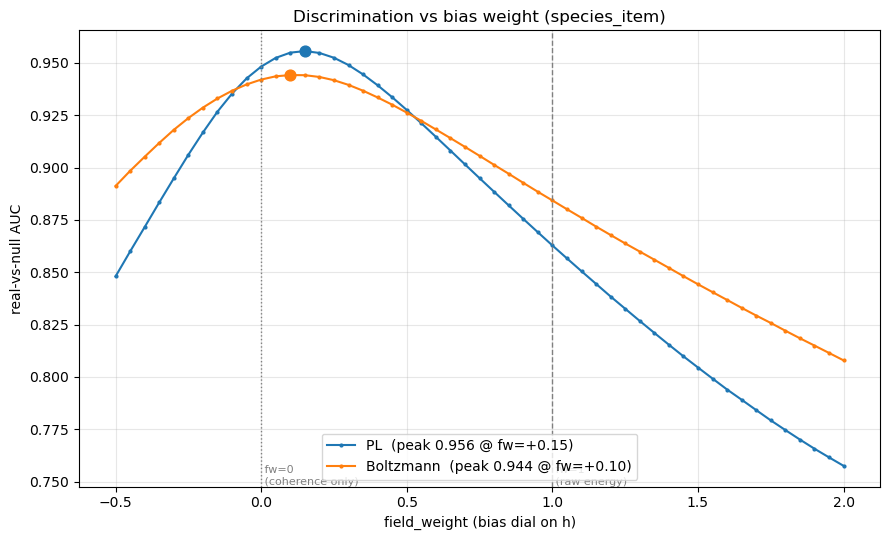

In [14]:
# ── field_weight sweep ────────────────────────────────────────────────────────
field_weights = np.linspace(-0.5, 2.0, 51)

def auc_at_fw(d, fw):
    return auc(fw * d["r_pop"] + d["r_coh"], fw * d["n_pop"] + d["n_coh"])

fig, ax = plt.subplots(figsize=(9, 5.5))

print(f"{'model':<12} {'peak AUC':>9} {'@ fw':>6}   {'fw=0':>6} {'fw=1':>6}")
print("-" * 44)
for name in models:
    d = disc[name]
    aucs = np.array([auc_at_fw(d, fw) for fw in field_weights])
    bi = int(aucs.argmax())
    line, = ax.plot(
        field_weights, aucs, marker=".", markersize=4,
        label=f"{name}  (peak {aucs[bi]:.3f} @ fw={field_weights[bi]:+.2f})",
    )
    ax.scatter([field_weights[bi]], [aucs[bi]], color=line.get_color(), zorder=5, s=60)
    i0 = int(np.argmin(np.abs(field_weights)))
    i1 = int(np.argmin(np.abs(field_weights - 1.0)))
    print(f"{name:<12} {aucs[bi]:>9.3f} {field_weights[bi]:>+6.2f}   "
          f"{aucs[i0]:>6.3f} {aucs[i1]:>6.3f}")

ax.axvline(0.0, color="gray", ls=":", lw=1)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.text(0.0, ax.get_ylim()[0], " fw=0\n (coherence only)", va="bottom", fontsize=8, color="gray")
ax.text(1.0, ax.get_ylim()[0], " fw=1\n (raw energy)", va="bottom", fontsize=8, color="gray")
ax.set_xlabel("field_weight (bias dial on h)")
ax.set_ylabel("real-vs-null AUC")
ax.set_title(f"Discrimination vs bias weight ({MODEL})")
ax.grid(alpha=0.3)
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

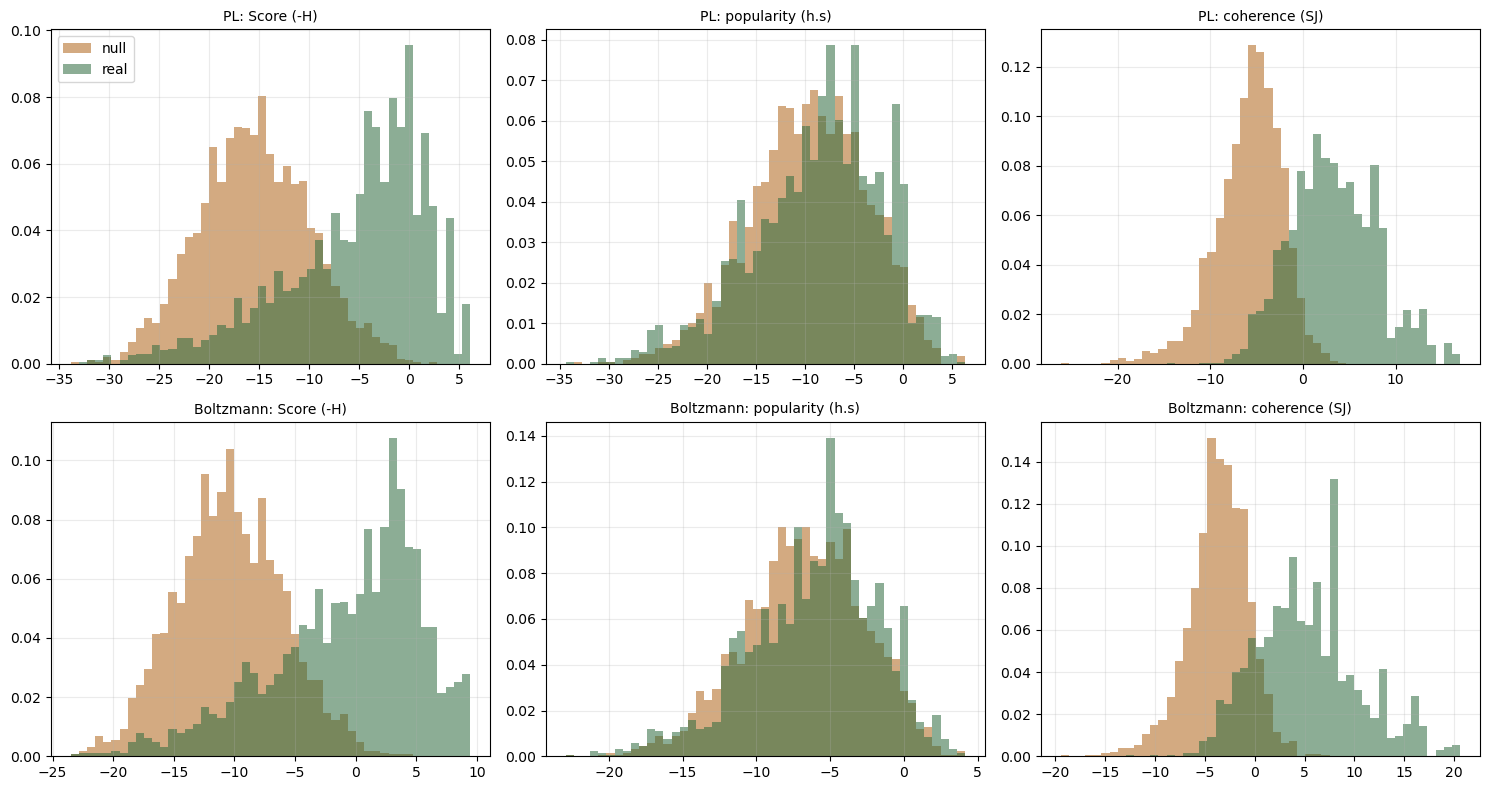

In [15]:
# ── Score distributions (full Score, popularity, coherence) ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, name in enumerate(models):
    d = disc[name]
    for c, (title, rk, nk) in enumerate([
        ("Score (-H)", "r_score", "n_score"),
        ("popularity (h.s)", "r_pop", "n_pop"),
        ("coherence (SJ)", "r_coh", "n_coh"),
    ]):
        ax = axes[r, c]
        lo = min(d[rk].min(), d[nk].min())
        hi = max(d[rk].max(), d[nk].max())
        bins = np.linspace(lo, hi, 50)
        ax.hist(d[nk], bins=bins, alpha=0.55, label="null", color="#b0651a", density=True)
        ax.hist(d[rk], bins=bins, alpha=0.55, label="real", color="#2e6b3f", density=True)
        ax.set_title(f"{name}: {title}", fontsize=10)
        ax.grid(alpha=0.25)
        if r == 0 and c == 0:
            ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ── Score centering / shape at fw=1 (real test teams) ─────────────────────────
# NOTE: where 0 falls and the overall shift are GAUGE-dependent (h -> h + c*1
# shifts every team's score by k*c), so "% > 0" is a centering readout, not a
# discrimination one -- Metric 3 already showed real-vs-null AUC is a wash between
# the fits. PL's strongly-negative logistic intercepts push most teams below 0
# (only high-coherence teams clear it); Boltzmann's min-norm / moment-matched
# field centers the bulk near 0, making the Score's sign interpretable.
from scipy.stats import skew

print(f"{'model':<12} {'median':>8} {'% > 0':>7} {'skew':>7} {'IQR':>8}")
print("-" * 44)
for name in models:
    sc = disc[name]["r_score"]
    q1, q3 = np.percentile(sc, [25, 75])
    print(f"{name:<12} {np.median(sc):>8.3f} {np.mean(sc > 0):>6.1%} "
          f"{skew(sc):>7.3f} {q3 - q1:>8.3f}")

model          median   % > 0    skew      IQR
--------------------------------------------
PL             -3.767  21.1%  -0.999    9.040
Boltzmann       0.590  53.1%  -0.790    8.197


## Metric 4: Held-out moment calibration (PT-sampled — production path)

Boltzmann matches empirical marginals and **connected** pair moments
$\langle s_i s_j\rangle - \langle s_i\rangle\langle s_j\rangle$ on training data by
construction. The question is whether that calibration **generalizes** to the test set.

The honest test samples each fitted model under **free parallel-tempered generation at
fw=1** (`estimate_moments`, the same sampler the webapp runs) and compares the resulting
model moments against the empirical moments. This is critical: an earlier mean-field
version of this metric used the factorized approximation $C \approx \langle s\rangle
\langle s\rangle^\top$, which *discards the connected pair structure that is the entire
pairwise model* — so it measured neither model's couplings. The MF marginal scatter
below is kept only as a diagnostic of why MF misleads (it over-concentrates on PL's sharp
$J$); the PT table that follows is the real comparison.

On **train**, Boltzmann should reproduce the connected pair moments far better than PL
(that is what it was fit to do — the `boltzmann_learning.ipynb` headline). On **test**,
whichever model's moment match survives out-of-sample is the better-calibrated generator.

model        split   marginal r   MAE m   (MF -- diagnostic only)
----------------------------------------------------
PL           train       0.7290  0.0062
PL           test        0.7098  0.0063
Boltzmann    train       0.6375  0.0091
Boltzmann    test        0.5730  0.0102


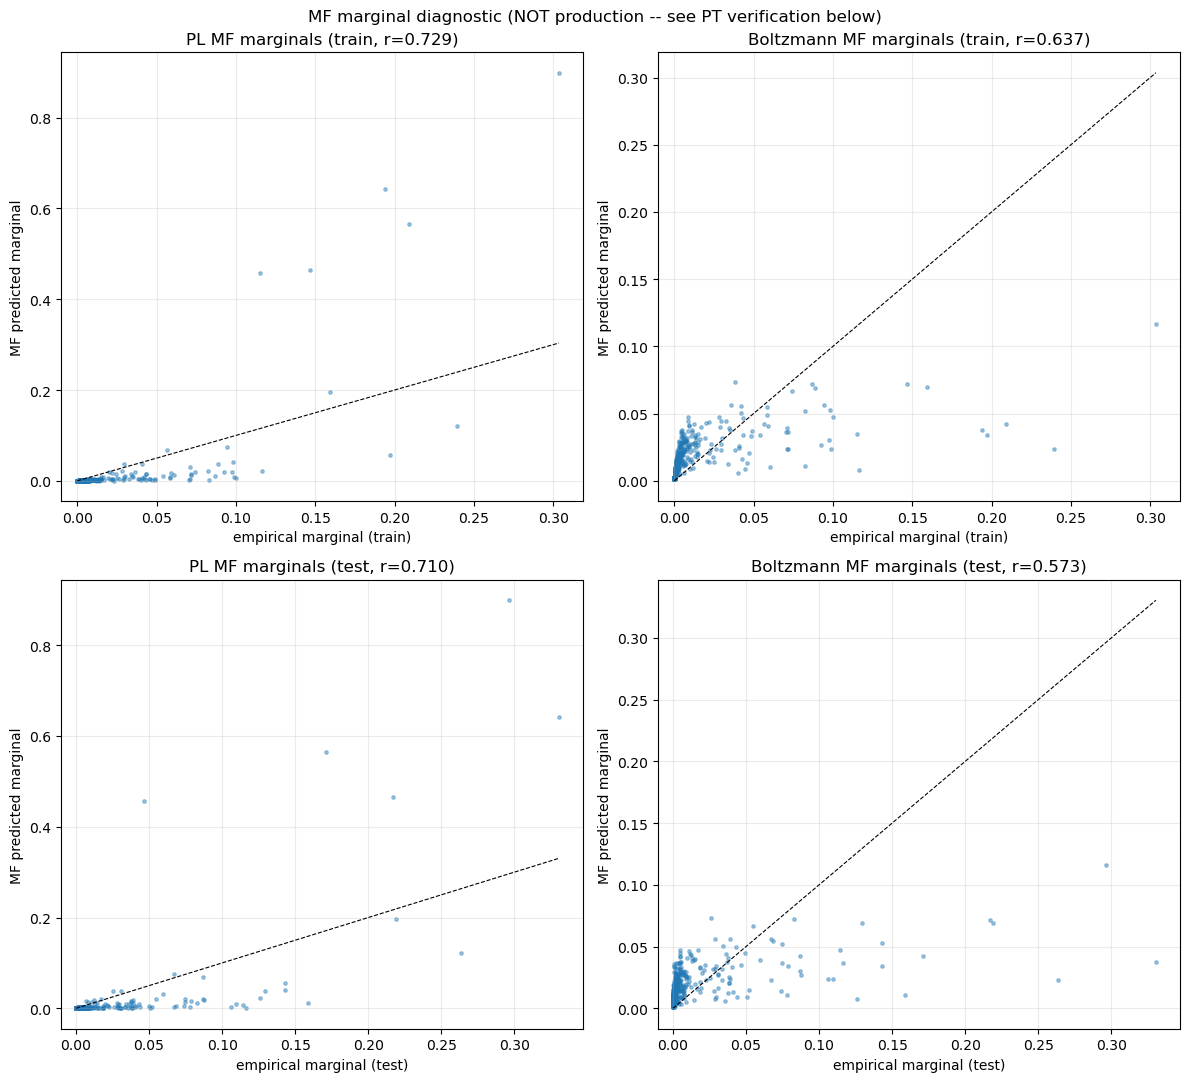

In [17]:
# ── Empirical moments on train and test ───────────────────────────────────────
m_data_train, C_data_train = empirical_moments(X_train_int, w)
m_data_test, C_data_test = empirical_moments(X_test.astype(np.int32))

# ── MF marginals: a DIAGNOSTIC, not the production path ───────────────────────
# Production inference is PT (see the next section). MF is shown here only to
# expose *why* it misleads on this comparison: it over-concentrates on PL's
# sharp couplings. The empirical marginal (x-axis) is identical across both
# models -- only the model prediction (y) differs -- so the x-limit is pinned to
# the empirical range to make that explicit (otherwise PL's runaway prediction
# drags the autoscaled frame and the two panels look like different data).
def mf_marginals(J, h, n_iters=500, tol=1e-6, damp=0.5):
    """Unconstrained MF marginals: iterate m = sigma(h + J @ m)."""
    m = expit(h)
    for _ in range(n_iters):
        m_new = expit(h + J @ m)
        delta = float(np.max(np.abs(m_new - m)))
        m = damp * m_new + (1.0 - damp) * m
        if delta < tol:
            break
    return m

offdiag = ~np.eye(V, dtype=bool)
iu_flat = np.triu_indices(V, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
print(f"{'model':<12} {'split':<6} {'marginal r':>11} {'MAE m':>7}   "
      f"(MF -- diagnostic only)")
print("-" * 52)

for ci, name in enumerate(models):
    J, h = models[name]
    m_mf = mf_marginals(J, h)

    for ri, (split_label, m_emp) in enumerate([
        ("train", m_data_train),
        ("test",  m_data_test),
    ]):
        r_m = float(np.corrcoef(m_mf, m_emp)[0, 1])
        mae_m = float(np.mean(np.abs(m_mf - m_emp)))
        print(f"{name:<12} {split_label:<6} {r_m:>11.4f} {mae_m:>7.4f}")

        ax = axes[ri, ci]
        ax.scatter(m_emp, m_mf, s=6, alpha=0.4)
        x_hi = float(m_emp.max())
        ax.plot([0, x_hi], [0, x_hi], "k--", lw=0.8)     # diagonal over data range
        ax.set_xlim(-0.01, x_hi * 1.05)                  # x is identical across models
        ax.set_xlabel(f"empirical marginal ({split_label})")
        ax.set_ylabel("MF predicted marginal")
        ax.set_title(f"{name} MF marginals ({split_label}, r={r_m:.3f})")
        ax.grid(alpha=0.25)

fig.suptitle("MF marginal diagnostic (NOT production -- see PT verification below)")
plt.tight_layout()
plt.show()

In [18]:
# ── PT moment reconstruction (production path) ────────────────────────────────
# Sample each TRAIN-fit model under free parallel-tempered generation at fw=1 --
# the cold chain (T=1) samples P ∝ exp(-H), exactly what the webapp does. This is
# the slow cell: lower PT_N_RUNS for a quick pass, raise it to tighten the MC
# noise floor (the model side of the moment match is a sample estimate).
from k2dex.sampling import estimate_moments

PT_N_RUNS = 10   # estimate_moments' calibrated default is 25; 10 is a faster check

pt_moments = {}
for name, (J, h) in models.items():
    res = estimate_moments(
        J, h, TEAM_SIZE,
        species_of=species_of, item_of=item_of,
        field_weight=1.0, n_runs=PT_N_RUNS, seed=SEED,
        progress=True
    )
    if res is None:
        raise RuntimeError(f"{name}: estimate_moments over-constrained")
    m_mod, C_mod, diag = res
    pt_moments[name] = (m_mod, C_mod)
    print(f"{name:<12} n_samples={diag['n_samples']:>7}  "
          f"local_acc={diag['local_accept']:.2f}  swap_acc={diag['swap_accept']:.2f}")


def connected_upper(C, m):
    """Upper-triangle connected pair moments <s_i s_j> - <s_i><s_j>."""
    return (C - np.outer(m, m))[iu_flat]


# Marginals + connected pair moments vs train and test empirical, both models.
print(f"\n{'model':<12} {'split':<6} {'marg r':>7} {'marg MAE':>9} "
      f"{'conn-pair r':>12} {'conn MAE':>10}")
print("-" * 60)
for name in models:
    m_mod, C_mod = pt_moments[name]
    conn_mod = connected_upper(C_mod, m_mod)
    for split, m_emp, C_emp in [("train", m_data_train, C_data_train),
                                ("test",  m_data_test,  C_data_test)]:
        conn_emp = connected_upper(C_emp, m_emp)
        r_m = float(np.corrcoef(m_mod, m_emp)[0, 1])
        mae_m = float(np.mean(np.abs(m_mod - m_emp)))
        r_c = float(np.corrcoef(conn_mod, conn_emp)[0, 1])
        mae_c = float(np.mean(np.abs(conn_mod - conn_emp)))
        print(f"{name:<12} {split:<6} {r_m:>7.3f} {mae_m:>9.4f} "
              f"{r_c:>12.3f} {mae_c:>10.5f}")

PL           n_samples=  36000  local_acc=0.33  swap_acc=0.67


Boltzmann    n_samples=  36000  local_acc=0.46  swap_acc=0.73

model        split   marg r  marg MAE  conn-pair r   conn MAE
------------------------------------------------------------
PL           train    0.912    0.0039        0.720    0.00003
PL           test     0.849    0.0043        0.524    0.00004
Boltzmann    train    0.992    0.0010        0.932    0.00002
Boltzmann    test     0.937    0.0029        0.687    0.00004


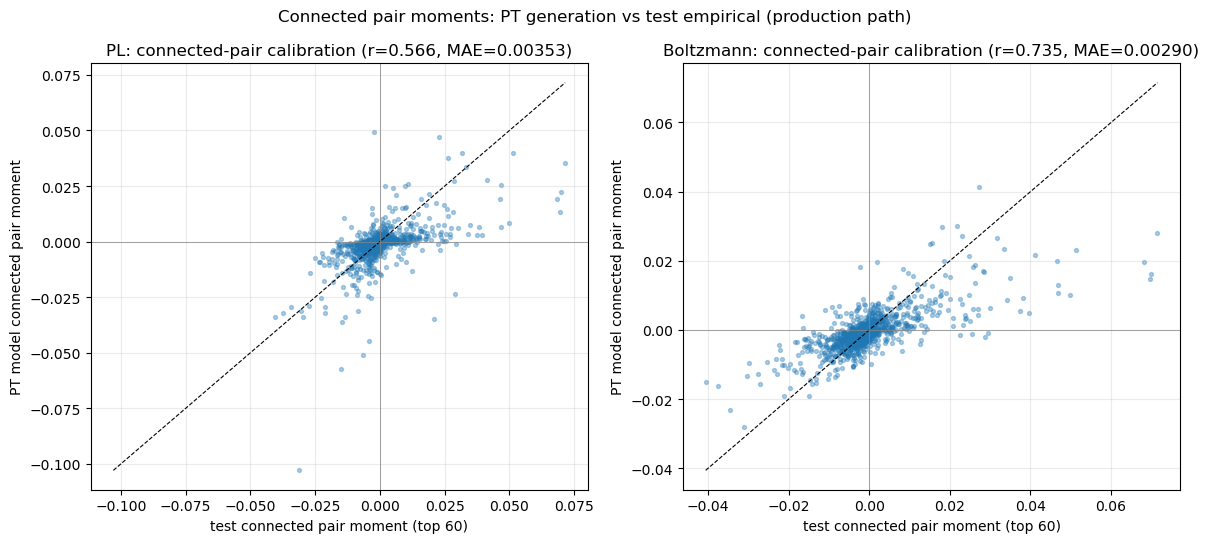

In [19]:
# ── Connected-pair scatter: PT model vs test empirical (top-K features) ────────
K_TOP = min(60, V)
top_idx = np.argsort(m_data_train)[::-1][:K_TOP]
iu_top = np.triu_indices(K_TOP, 1)

conn_test_top = (
    C_data_test - np.outer(m_data_test, m_data_test)
)[np.ix_(top_idx, top_idx)][iu_top]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ci, name in enumerate(models):
    m_mod, C_mod = pt_moments[name]
    conn_mod_top = (
        C_mod - np.outer(m_mod, m_mod)
    )[np.ix_(top_idx, top_idx)][iu_top]

    r = float(np.corrcoef(conn_mod_top, conn_test_top)[0, 1])
    mae = float(np.mean(np.abs(conn_mod_top - conn_test_top)))

    ax = axes[ci]
    ax.scatter(conn_test_top, conn_mod_top, s=8, alpha=0.35)
    lo = min(conn_test_top.min(), conn_mod_top.min())
    hi = max(conn_test_top.max(), conn_mod_top.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel(f"test connected pair moment (top {K_TOP})")
    ax.set_ylabel("PT model connected pair moment")
    ax.set_title(f"{name}: connected-pair calibration (r={r:.3f}, MAE={mae:.5f})")
    ax.grid(alpha=0.25)

fig.suptitle("Connected pair moments: PT generation vs test empirical (production path)")
plt.tight_layout()
plt.show()

## Metric 5: Outcome association (Score/coherence vs placement)

Composition explains very little of placement variance (ICC ceiling ~4% from
`outcome_ceiling.ipynb`). But the question here is whether PL and Boltzmann differ in
what little signal exists. We score every team with both models, correlate against
placement, and compare.

This uses the **full corpus** (no train/test split): placement is never a fit input, so
in-sample scoring is not circular (see `outcome_validation.ipynb`). Both models are fit
on the full corpus for maximum power, then each team's coherence, popularity, and Score
are correlated with its placement percentile.

In [20]:
# ── Full-corpus fits for outcome analysis ─────────────────────────────────────
all_teams_full = tournament_ingest.all_teams(tournaments)
all_obs = tournament_ingest.all_team_observations(tournaments)
all_ref = max(t.meta.date for t in tournaments)

# Fit weighting for the outcome analysis. The production models are recency-
# weighted, so that's the default. Set OUTCOME_WEIGHTED=False to reproduce
# outcome_validation.ipynb's *unweighted* fit -- there coherence-vs-placement was
# slightly NEGATIVE; the weighted fit concentrates (J,h) on the matured meta and
# lifts it slightly positive. The fit changed, not the placement signal.
OUTCOME_WEIGHTED = True
if OUTCOME_WEIGHTED:
    w_all = team_weights(
        all_obs, reference_date=all_ref,
        recency_tau=RECENCY_TAU_DAYS, in_person_multiplier=IN_PERSON_WEIGHT,
    )
else:
    w_all = np.ones(len(all_obs), dtype=np.float64)

vocab_all, feat_to_idx_all, X_all, sp_all, it_all = build_vocab_and_matrix(
    all_teams_full, w_all,
)
V_all = len(vocab_all)
X_all_int = X_all.astype(np.int32)

J_pl_all, h_pl_all = fit_pl_ising(X_all_int, C=1.0 / LAM, sample_weight=w_all)

bz_kw_all = dict(BZ_OPTS)
sm_all = bz_kw_all.pop("support_min_count", None)
smask_all = None
if sm_all is not None:
    cooc_all = X_all_int.astype(np.int64).T @ X_all_int.astype(np.int64)
    smask_all = cooc_all >= int(sm_all)

J_bz_all, h_bz_all, _ = fit_boltzmann_ising(
    X_all_int, team_size=TEAM_SIZE, sample_weight=w_all,
    init_J=J_pl_all, init_h=h_pl_all,
    species_of=sp_all, item_of=it_all,
    support_mask=smask_all, seed=SEED + 1000,
    **bz_kw_all,
)

models_all = {"PL": (J_pl_all, h_pl_all), "Boltzmann": (J_bz_all, h_bz_all)}
print(f"full-corpus vocab: {V_all}   teams: {X_all.shape[0]}   weighted: {OUTCOME_WEIGHTED}")

boltzmann fit:   0%|          | 0/500 [00:00<?, ?it/s]

full-corpus vocab: 904   teams: 25704   weighted: True


In [21]:
# ── Score every team + attach outcomes ─────────────────────────────────────────
def scored_table(tournaments_list, feat_to_idx_loc, V_loc, J, h, *, model=MODEL):
    """Score each team and attach placement / win-rate outcomes."""
    rows, ppct, wrate = [], [], []
    for t in tqdm(tournaments_list, desc="Scoring teams"):
        placed = [tm.placing for tm in t.teams if tm.placing is not None]
        field = max(placed) if placed else None
        for tm in t.teams:
            idx = team_to_indices(tm.members, feat_to_idx_loc, model=model)
            if idx is None:
                continue
            v = np.zeros(V_loc, dtype=bool)
            v[idx] = True
            rows.append(v)
            if tm.placing is not None and field and field > 1:
                ppct.append(1.0 - (tm.placing - 1) / (field - 1))
            else:
                ppct.append(np.nan)
            g = tm.wins + tm.losses + tm.ties
            wrate.append(tm.wins / g if g > 0 else np.nan)
    s = np.array(rows, dtype=np.float64)
    pop = s @ h
    coh = 0.5 * np.sum(s * (s @ J), axis=1)
    return {
        "coherence": coh, "popularity": pop, "score": pop + coh,
        "placement_pct": np.array(ppct), "winrate": np.array(wrate),
    }


def assoc(tbl, x_key, y_key):
    x, y = tbl[x_key], tbl[y_key]
    m = ~(np.isnan(x) | np.isnan(y))
    rho, p = spearmanr(x[m], y[m])
    return rho, p, int(m.sum())


print(f"{'model':<12} {'predictor':<12} {'outcome':<14} {'spearman':>9} {'p':>10} {'n':>7}")
print("-" * 70)
for name, (J, h) in models_all.items():
    tbl = scored_table(tournaments, feat_to_idx_all, V_all, J, h)
    for pred in ["coherence", "popularity", "score"]:
        for outc in ["placement_pct", "winrate"]:
            rho, p, n = assoc(tbl, pred, outc)
            print(f"{name:<12} {pred:<12} {outc:<14} {rho:>+9.4f} {p:>10.2e} {n:>7}")

model        predictor    outcome         spearman          p       n
----------------------------------------------------------------------


Scoring teams: 100%|██████████| 287/287 [00:00<00:00, 2610.09it/s]


PL           coherence    placement_pct    +0.0478   1.88e-12   21661
PL           coherence    winrate          +0.0512   2.16e-15   23997
PL           popularity   placement_pct    +0.1273   6.61e-79   21661
PL           popularity   winrate          +0.1403  1.11e-105   23997
PL           score        placement_pct    +0.1594  3.64e-123   21661
PL           score        winrate          +0.1773  1.09e-168   23997


Scoring teams: 100%|██████████| 287/287 [00:00<00:00, 3999.38it/s]


Boltzmann    coherence    placement_pct    +0.0711   1.19e-25   21661
Boltzmann    coherence    winrate          +0.0785   3.74e-34   23997
Boltzmann    popularity   placement_pct    +0.1213   9.79e-72   21661
Boltzmann    popularity   winrate          +0.1326   1.67e-94   23997
Boltzmann    score        placement_pct    +0.1518  9.50e-112   21661
Boltzmann    score        winrate          +0.1702  1.95e-155   23997


Scoring teams: 100%|██████████| 287/287 [00:00<00:00, 4086.68it/s]


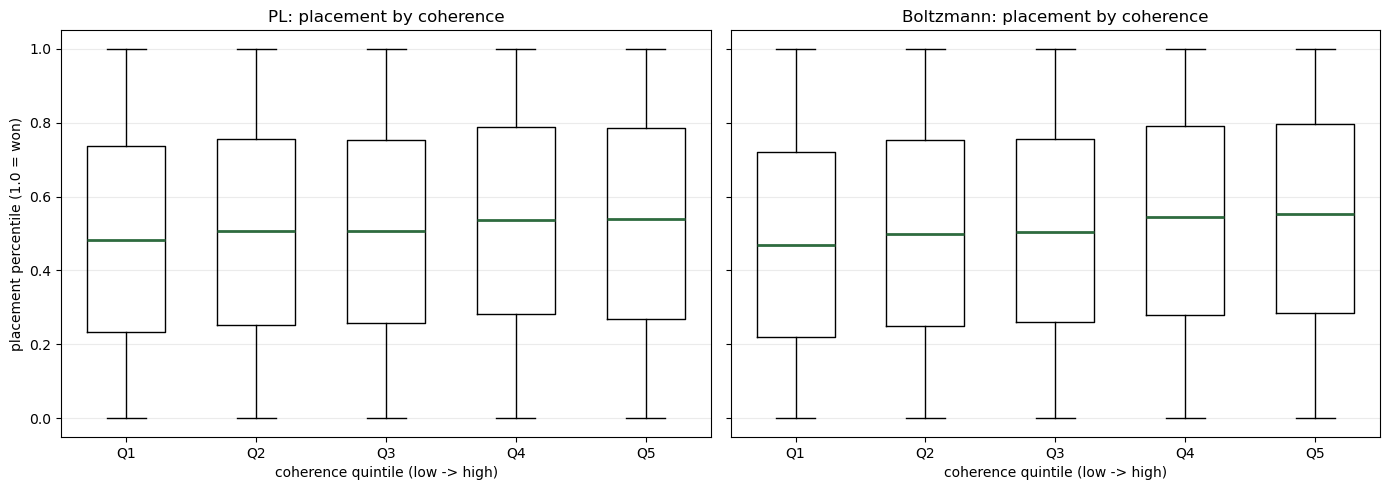

In [22]:
# ── Coherence quintile view (placement by coherence bin) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ci, name in enumerate(models_all):
    J, h = models_all[name]
    tbl = scored_table(tournaments, feat_to_idx_all, V_all, J, h)
    coh = tbl["coherence"]
    ppct = tbl["placement_pct"]
    mask = ~np.isnan(ppct)
    coh, ppct = coh[mask], ppct[mask]

    edges = np.quantile(coh, np.linspace(0, 1, 6))
    edges[-1] += 1e-9
    b = np.clip(np.digitize(coh, edges[1:-1]), 0, 4)
    groups = [ppct[b == k] for k in range(5)]

    ax = axes[ci]
    ax.boxplot(groups, showfliers=False, widths=0.6,
               medianprops=dict(color="#2e6b3f", linewidth=2))
    ax.set_xticklabels([f"Q{k+1}" for k in range(5)])
    ax.set_xlabel("coherence quintile (low -> high)")
    ax.set_title(f"{name}: placement by coherence")
    ax.grid(alpha=0.25, axis="y")

axes[0].set_ylabel("placement percentile (1.0 = won)")
plt.tight_layout()
plt.show()

In [23]:
# ── New signal or gauge redistribution? ───────────────────────────────────────
# Boltzmann's coherence-placement correlation is higher than PL's, but its Score
# (popularity + coherence, the gauge-invariant total) is the same. This nested
# rank-regression decides whether coherence adds *incremental* outcome signal
# beyond popularity, per model:
#   - R2(pop)            : popularity alone
#   - R2(pop + coh)      : the joint fit == Score's predictive content
#   - incremental R2     : what coherence buys on top of popularity
#   - partial Spearman   : corr(coherence, placement | popularity)
# If Boltzmann's coherence is NEW signal, its incremental R2 / partial beat PL's.
# If it's redistribution, R2(pop+coh) matches across models and coherence's
# incremental piece just trades off against the (lowered) popularity term.
def outcome_decomp(tbl, outcome="placement_pct"):
    y, pop, coh = tbl[outcome], tbl["popularity"], tbl["coherence"]
    m = ~(np.isnan(y) | np.isnan(pop) | np.isnan(coh))

    def z(a):
        r = rankdata(a)
        return (r - r.mean()) / r.std()

    yr, pr, cr = z(y[m]), z(pop[m]), z(coh[m])
    n = len(yr)

    def r2(*cols):
        X = np.column_stack([np.ones(n), *cols])
        beta, *_ = np.linalg.lstsq(X, yr, rcond=None)
        resid = yr - X @ beta
        return 1.0 - float(resid @ resid) / n   # yr standardized -> SST = n

    r2_pop = r2(pr)
    r2_both = r2(pr, cr)

    # partial Spearman coh|pop: residualize both on popularity, then correlate.
    P = np.column_stack([np.ones(n), pr])
    ry = yr - P @ np.linalg.lstsq(P, yr, rcond=None)[0]
    rc = cr - P @ np.linalg.lstsq(P, cr, rcond=None)[0]
    partial = float(np.corrcoef(ry, rc)[0, 1])
    return r2_pop, r2_both, r2_both - r2_pop, partial


print(f"{'model':<12} {'outcome':<14} {'R2(pop)':>8} {'R2(pop+coh)':>12} "
      f"{'incr R2':>9} {'partial coh|pop':>16}")
print("-" * 75)
for name, (J, h) in models_all.items():
    tbl = scored_table(tournaments, feat_to_idx_all, V_all, J, h)
    for outc in ["placement_pct", "winrate"]:
        r2p, r2b, incr, partial = outcome_decomp(tbl, outc)
        print(f"{name:<12} {outc:<14} {r2p:>8.4f} {r2b:>12.4f} "
              f"{incr:>9.4f} {partial:>+16.4f}")

model        outcome         R2(pop)  R2(pop+coh)   incr R2  partial coh|pop
---------------------------------------------------------------------------


Scoring teams: 100%|██████████| 287/287 [00:00<00:00, 3052.74it/s]


PL           placement_pct    0.0162       0.0252    0.0090          +0.0956
PL           winrate          0.0197       0.0303    0.0106          +0.1042


Scoring teams: 100%|██████████| 287/287 [00:00<00:00, 4039.18it/s]


Boltzmann    placement_pct    0.0147       0.0248    0.0101          +0.1013
Boltzmann    winrate          0.0176       0.0299    0.0123          +0.1118


## Summary

Five head-to-head metrics, each model at its own operating point. **The inference path
matters**: production ranking/generation is PT-MCMC, so MF-based numbers (Metric 1) are
proxies, not the production read.

| Metric | Tests | Inference path | Expected winner |
| :-- | :-- | :-- | :-- |
| Completion (MRR / hit-rate) | Conditional prediction (leave-k-out) | MF (proxy; PT to confirm) | PL (matches conditionals) |
| Held-out LPPL | The PL objective on test data | analytic | PL in-sample; open out-of-sample |
| Discrimination (AUC) | Real-vs-null scoring (fw swept) | direct energy (path-independent) | weak null — likely a wash |
| Moment calibration | Marginals + connected pairs on test | **PT (production)** | Boltzmann (fit to match moments) |
| Outcome association | Score/coherence vs placement | direct energy | wash (ceiling ~4%) |

**What the first run revealed (and the fix):**
- The MF marginal panels looked like different empirical data — they are not; identical
  data, an axis artifact from PL's MF marginals running away to ~0.9 (MF over-concentrates
  on PL's sharp $J$). The frame is now pinned to the empirical range.
- The original Metric 4 used the factorized $C \approx \langle s\rangle\langle s\rangle^\top$,
  which discards the connected pair structure — it tested neither model's couplings. It is
  replaced by PT-sampled connected moments (the real moment-calibration test).
- Discrimination peaking near fw≈0.1 (not 1.0) is the expected Fisher-mix behavior, not a
  bug; the fw≈1 calibration claim lives in Metric 4, not here.

**Reading the corrected results:**
- If Boltzmann wins **PT moment calibration** out-of-sample *and* ties/beats PL on a
  **PT-confirmed** completion check, it is the better production model.
- If Boltzmann wins moment calibration but PL wins completion, that is the expected
  conditionals-vs-moments split; the call depends on which surface (completer vs analysis)
  matters more.
- If PL matches Boltzmann even on PT moment calibration out-of-sample, Boltzmann's extra
  cost buys nothing downstream and PL stays the default.

## Results (Reg M-A species@item, run 2026-06-27)

Each model wins its own objective out-of-sample; the production (PT/MCMC) path favors
Boltzmann on the surfaces the app exposes.

| Axis | Metric | Result | Power |
| :-- | :-- | :-- | :-- |
| Joint generative | PT moment calibration (test) | **Boltzmann** — conn-pair r 0.69 vs 0.52, marg r 0.94 vs 0.85 | high (full vocab) |
| Conditional ranking | Completion MRR (MCMC, 150 teams) | **Boltzmann** — Δ +0.046 (k=1, P=99%), +0.030 (k=2, P=97%), +0.015 (k=3, P=91%) | moderate |
| Conditional calibration | Held-out LPPL (per-feature) | **PL** — −0.0132 vs −0.0187 | high (full test) |
| Discrimination | Real-vs-null AUC (fw swept) | wash — both ~0.95, peak at Fisher mix fw≈0.1 | path-independent |
| Outcome | Score/coherence vs placement | wash — ceiling ~few %; Boltzmann coherence slightly more predictive | high |

The completion edge holds at every k (paired bootstrap P ≥ 0.91, largest at k=1 where the
completer most often serves a single suggestion). A 95% CI grazing zero at k=3 is not the
right bar for a team builder — a ~91% chance Boltzmann ranks better is a real edge here.

**Key methodological finding: MF evaluation is biased against Boltzmann.** Mean-field is a
faithful ranking proxy for PL (MF-vs-MCMC Spearman ≈ 0.9) but **not** for Boltzmann (ρ
drops to ~0.70, degrading with k) — MF over-concentrates on PL's sharp `J` and understates
Boltzmann's joint ranking. The first MF-based pass wrongly favored PL on completion; the
production sampler reversed it. **Use PT/MCMC for any Boltzmann-vs-PL downstream comparison.**

**Verdict.** Boltzmann is the better all-around production model: it wins generative
calibration (decisive, generalizes) and completion ranking (at every k on the production
sampler). PL's only win — conditional probability calibration (LPPL) — is not surfaced
anywhere in the app (the completer ranks, it does not display calibrated probabilities).
**Promotion caveat** (CLAUDE.md): moment-matched `h` wants `field_weight ≈ 1`, unlike PL's
~0.3–0.5 — recheck the bias dial (Metric 3 sweep is the harness) before making it a default.